# A/B Testing Conversion Analysis

This project evaluates whether a new webpage design (treatment group) improves conversion rate compared with the original design (control group).

## Business Background

An online platform is testing two webpage versions:

- **Control**: original design
- **Treatment**: new design

The objective is to determine whether the new design significantly improves the conversion rate.

In [28]:
# Import libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Create folder for saving figures
os.makedirs("images", exist_ok=True)

# Helper function to save plots
def save_plot(filename):
    plt.savefig(f"images/{filename}.png", dpi=300, bbox_inches="tight")

In [29]:
# Simulate A/B testing data

np.random.seed(42)

n = 10000

group = np.random.choice(["control", "treatment"], size=n)

converted = []

for g in group:
    if g == "control":
        converted.append(np.random.binomial(1, 0.12))
    else:
        converted.append(np.random.binomial(1, 0.15))

df = pd.DataFrame({
    "user_id": range(1, n + 1),
    "group": group,
    "converted": converted
})

# Save dataset
os.makedirs("data", exist_ok=True)
df.to_csv("data/ab_test_data.csv", index=False)

df.head()

,user_id,group,converted
0,1,control,0
1,2,treatment,0
2,3,control,0
3,4,control,0
4,5,control,0


## Data Overview

We first inspect the dataset size, group balance, and conversion outcomes.

In [30]:
# Basic data overview

print("Dataset shape:", df.shape)
print("\nGroup counts:")
print(df["group"].value_counts())

print("\nConversion counts:")
print(df["converted"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (10000, 3)

Group counts:
group
control      5013
treatment    4987
Name: count, dtype: int64

Conversion counts:
converted
0    8670
1    1330
Name: count, dtype: int64

Missing values:
user_id      0
group        0
converted    0
dtype: int64


In [31]:
# Conversion rate by group

conversion_summary = df.groupby("group")["converted"].agg(["count", "sum", "mean"])
conversion_summary = conversion_summary.rename(columns={
    "count": "n_users",
    "sum": "n_converted",
    "mean": "conversion_rate"
})

print(conversion_summary)

           n_users  n_converted  conversion_rate
group                                           
control       5013          595         0.118691
treatment     4987          735         0.147383


## Conversion Rate by Group

We compare the conversion rate between the control and treatment groups.

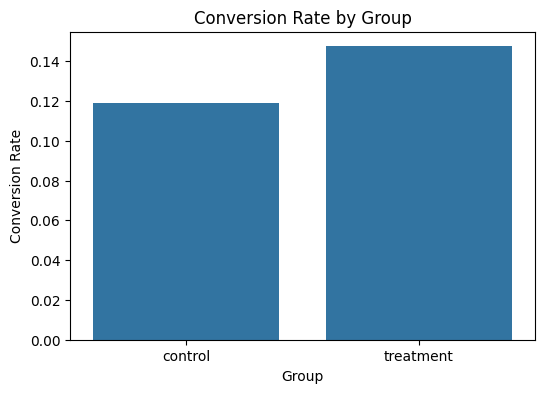

In [39]:
# Plot conversion rate by group

conversion_rates = df.groupby("group", as_index=False)["converted"].mean()

plt.figure(figsize=(6, 4))
sns.barplot(data=conversion_rates, x="group", y="converted")

plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")

save_plot("conversion_rate_by_group")
plt.show()

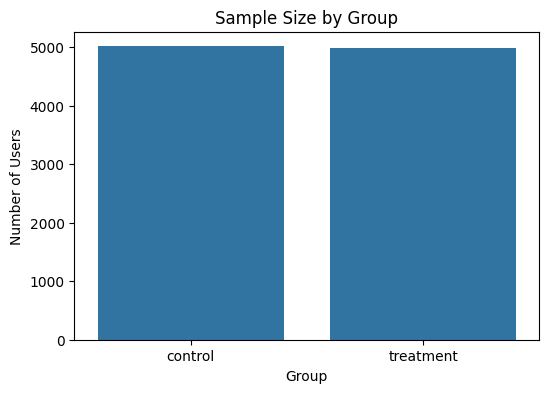

In [32]:
# Plot sample size by group

group_counts = df["group"].value_counts().reset_index()
group_counts.columns = ["group", "count"]

plt.figure(figsize=(6, 4))
sns.barplot(data=group_counts, x="group", y="count")

plt.title("Sample Size by Group")
plt.xlabel("Group")
plt.ylabel("Number of Users")

save_plot("sample_size_by_group")
plt.show()

## Hypothesis Setup

We test whether the treatment group has a different conversion rate from the control group.

- **Null hypothesis (H0):** conversion rate of treatment = conversion rate of control
- **Alternative hypothesis (H1):** conversion rate of treatment ≠ conversion rate of control

In [33]:
# Two-proportion z-test

control = df[df["group"] == "control"]["converted"]
treatment = df[df["group"] == "treatment"]["converted"]

success = np.array([treatment.sum(), control.sum()])
nobs = np.array([len(treatment), len(control)])

z_stat, p_value = proportions_ztest(success, nobs)

print("Z-statistic:", round(z_stat, 4))
print("P-value:", round(p_value, 6))

Z-statistic: 4.2247
P-value: 2.4e-05


In [34]:
# Conversion rate difference

control_rate = control.mean()
treatment_rate = treatment.mean()
diff = treatment_rate - control_rate

print("Control conversion rate:", round(control_rate, 4))
print("Treatment conversion rate:", round(treatment_rate, 4))
print("Difference (Treatment - Control):", round(diff, 4))

Control conversion rate: 0.1187
Treatment conversion rate: 0.1474
Difference (Treatment - Control): 0.0287


In [35]:
# Confidence intervals for each group

control_ci = proportion_confint(control.sum(), len(control), alpha=0.05, method="normal")
treatment_ci = proportion_confint(treatment.sum(), len(treatment), alpha=0.05, method="normal")

print("Control 95% CI:", tuple(round(x, 4) for x in control_ci))
print("Treatment 95% CI:", tuple(round(x, 4) for x in treatment_ci))

Control 95% CI: (0.1097, 0.1276)
Treatment 95% CI: (0.1375, 0.1572)


## Conversion Rate with Confidence Intervals

We visualize the conversion rates along with 95% confidence intervals for both groups.

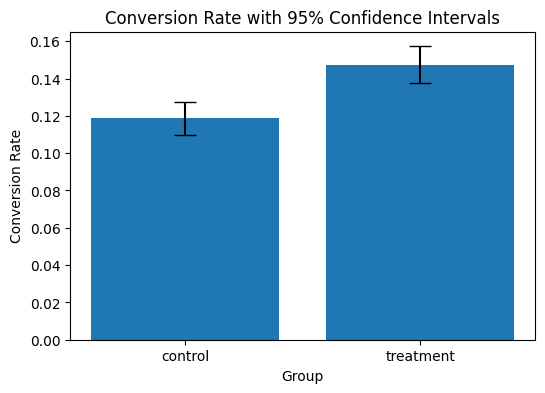

In [36]:
# Plot conversion rates with confidence intervals

summary_plot = pd.DataFrame({
    "group": ["control", "treatment"],
    "conversion_rate": [control_rate, treatment_rate],
    "ci_lower": [control_ci[0], treatment_ci[0]],
    "ci_upper": [control_ci[1], treatment_ci[1]]
})

summary_plot["error"] = summary_plot["ci_upper"] - summary_plot["conversion_rate"]

plt.figure(figsize=(6, 4))
plt.bar(summary_plot["group"], summary_plot["conversion_rate"], yerr=summary_plot["error"], capsize=8)

plt.title("Conversion Rate with 95% Confidence Intervals")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")

save_plot("conversion_rate_confidence_interval")
plt.show()

In [37]:
# Final summary table

results = pd.DataFrame({
    "Metric": [
        "Control Conversion Rate",
        "Treatment Conversion Rate",
        "Difference",
        "Z-statistic",
        "P-value"
    ],
    "Value": [
        round(control_rate, 4),
        round(treatment_rate, 4),
        round(diff, 4),
        round(z_stat, 4),
        round(p_value, 6)
    ]
})

results

,Metric,Value
0,Control Conversion Rate,0.118700
1,Treatment Conversion Rate,0.147400
2,Difference,0.028700
3,Z-statistic,4.224700
4,P-value,0.000024


In [38]:
# Automatically generate conclusion text

alpha = 0.05

print("A/B Test Conclusion")
print("-" * 40)

if p_value < alpha:
    print("The difference in conversion rates is statistically significant.")
    print("Treatment performs significantly differently from Control.")
    
    if treatment_rate > control_rate:
        print("Treatment has a higher conversion rate, so Variant B is preferred.")
    else:
        print("Treatment has a lower conversion rate, so Variant A is preferred.")
else:
    print("The difference in conversion rates is not statistically significant.")
    print("There is insufficient evidence to conclude that the treatment changed conversion performance.")

A/B Test Conclusion
----------------------------------------
The difference in conversion rates is statistically significant.
Treatment performs significantly differently from Control.
Treatment has a higher conversion rate, so Variant B is preferred.


## Conclusion

The treatment group achieved a higher conversion rate than the control group.  
Based on the two-proportion z-test, we evaluate whether this difference is statistically significant.

If the p-value is below 0.05, we conclude that the new design improves conversion performance and should be considered for deployment.